### Middleware

Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:
1. tracking agent behaviour with logging, analytics, and debugging
2. Transforming prompts, tool selection, and output formatting
3. Adding retries, fallbacks and early termination logic.
4. Applying rate limits, guardrails, and PII detection

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

### Summarisation Middleware

Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Smmarization is useful for the following:

1. Long-running conversations that exceed context windows.
2. Multi-turn dialouges with extensive history.
3. Applications where preserving full conversation context matters.

In [4]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

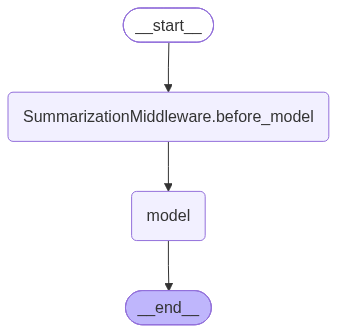

In [6]:
## Messagebased Summarization

agent = create_agent(
    model="gpt-5",
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="gpt-5",
            trigger=("messages",10),
            keep=("messages",4) 
        )
    ]
)

agent

In [7]:
### Run with thread id
config={"configurable":{"thread_id":"test-1"}}

In [9]:
## Alternative test data
questions = [
    "what is 2+2",
    "what is 10*5",
    "what is 200/4",
    "what is 15-7",
    "what is 15*15",
    "what is 4*4",
    "what is 10-2",
    "what is 1/1",
    "what is 16/4",
    "what is 18/2",
    "what is 10/2"
]

for q in questions:
    response=agent.invoke({"messages": [HumanMessage(content=q)]},config)
    print(f"Messages: {response}")
    print(f"Messages: {len(response['messages'])}")  

Messages: {'messages': [HumanMessage(content='Here is a summary of the conversation to date:\n\n## SESSION INTENT\nAnswer a sequence of basic arithmetic questions with concise, direct numeric results.\n\n## SUMMARY\n- User asked: 2+2; assistant answered: 4.\n- User asked: 10*5; assistant answered: 50.\n- User asked: 200/4; assistant answered: 50.\n- User asked: 15-7; this is pending.\n- Style established: respond with just the numeric answer, no explanation.\n\n## ARTIFACTS\nNone\n\n## NEXT STEPS\n- Answer the pending question: 15-7 = 8.\n- Continue providing direct numeric answers to any subsequent arithmetic queries.', additional_kwargs={'lc_source': 'summarization'}, response_metadata={}, id='c8b61e9c-42d2-403b-bb2d-255fa0489793'), AIMessage(content='8', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 63, 'total_tokens': 73, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_t

In [12]:
from langchain_core.tools import tool

@tool
def search_hotels(city:str) -> str:
    """Search hotels - returns long response to use more tokens."""
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, gym, pool,wifi, 350/night,
    2. City Inn - 4 star gym, pool,wifi, 2250/night,
    3. Budget Stay - 3 star gym, pool,wifi, 150/night
    """
    
agent = create_agent(
    model="gpt-5",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="gpt-5",
            trigger=("tokens",250),
            keep=("tokens",200)
        )
    ]
)

config={"configurable":{"thread_id":"test-2"}}

In [13]:
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4 # 4 chars ~ 1 token

In [14]:
#Run test

cities = ["paris","london","tokyo","new york","dubai","singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Find hotels in {city}")]},
        config=config
    )
    
    tokens = count_tokens(response["messages"])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

paris: ~183 tokens, 4 messages
[HumanMessage(content='Find hotels in paris', additional_kwargs={}, response_metadata={}, id='6c3099e9-23c9-4fc3-a645-8823c989590f'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 152, 'prompt_tokens': 134, 'total_tokens': 286, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 128, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EPWN7PZl9hQw2xC6z3hpAszXIHst7', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0b57e-3f43-7af2-acf3-aa3703b72ccd-0', tool_calls=[{'name': 'search_hotels', 'args': {'city': 'Paris'}, 'id': 'call_FDssIE4WOyF5CH0o9cJEE0bl', 